In [106]:
#conda install openpyxl

In [185]:
#importation des bibliotheques importantes
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
import numpy as np
from pathlib import Path
warnings.filterwarnings(action='ignore')
import os
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [186]:
excel_path = "/home/merveille/Projets/DataAna/Base Kidney diseases.xlsx"
pickle_path = "/home/merveille/Projets/DataAna/data.pkl"

if os.path.exists(pickle_path):
    data = pd.read_pickle(pickle_path)
    print("Dataset chargé depuis data.pkl")
else:
    data = pd.read_excel(excel_path)
    data.to_pickle(pickle_path)
    print("Excel chargé puis sauvegardé en pickle")

Dataset chargé depuis data.pkl


In [187]:
data.head(10)

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,2024-02-01 00:00:00,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,2024-02-05 00:00:00,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,2024-02-01 00:00:00,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,2024-01-01 00:00:00,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,2024-09-03 00:00:00,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,2024-01-01 00:00:00,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,2024-06-04 00:00:00,no,no,no,good,no,no,ckd
5,5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,notpresent,notpresent,...,39,7800,2024-04-04 00:00:00,yes,yes,no,good,yes,no,ckd
6,6,68.0,70.0,2024-01-01 00:00:00,0.0,0.0,NaN,normal,notpresent,notpresent,...,36,NaN,NaN,no,no,no,good,no,no,ckd
7,7,24.0,NaN,1.015,2.0,4.0,normal,abnormal,notpresent,notpresent,...,44,6900,5,no,yes,no,good,yes,no,ckd
8,8,52.0,100.0,1.015,3.0,0.0,normal,abnormal,present,notpresent,...,33,9600,4.0,yes,yes,no,good,no,yes,ckd
9,9,53.0,90.0,2024-02-01 00:00:00,2.0,0.0,abnormal,abnormal,present,notpresent,...,29,12100,2024-07-03 00:00:00,yes,yes,no,poor,no,yes,ckd


In [188]:
# Variables de référence
numerical_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
categorical_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
target_col = 'classification'

In [189]:
#je supprime la colonne 'id' car elle est inutile
if 'id' in data.columns:
    data = data.drop(columns=['id'])

In [190]:
dc=data.columns
dc

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [191]:
#types de valeurs
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    object 
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    object 
 11  sc              383 non-null    object 
 12  sod             313 non-null    object 
 13  pot             312 non-null    object 
 14  hemo            348 non-null    object 
 15  pcv             330 non-null    object 
 16  wc              295 non-null    object 
 17  rc              270 non-null    obj

In [192]:
data.describe()

,age,bp,al,su,bgr
count,391.000000,388.000000,354.000000,351.000000,356.000000
mean,51.483376,76.469072,1.016949,0.450142,148.036517
std,17.169714,13.683637,1.352679,1.099191,79.281714
min,2.000000,50.000000,0.000000,0.000000,22.000000
25%,42.000000,70.000000,0.000000,0.000000,99.000000
50%,55.000000,80.000000,0.000000,0.000000,121.000000
75%,64.500000,80.000000,2.000000,0.000000,163.000000
max,90.000000,180.000000,5.000000,5.000000,490.000000


In [193]:
# On convertit tout ce qui est numérique. Les erreurs deviennent des NaN.
for col in numerical_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

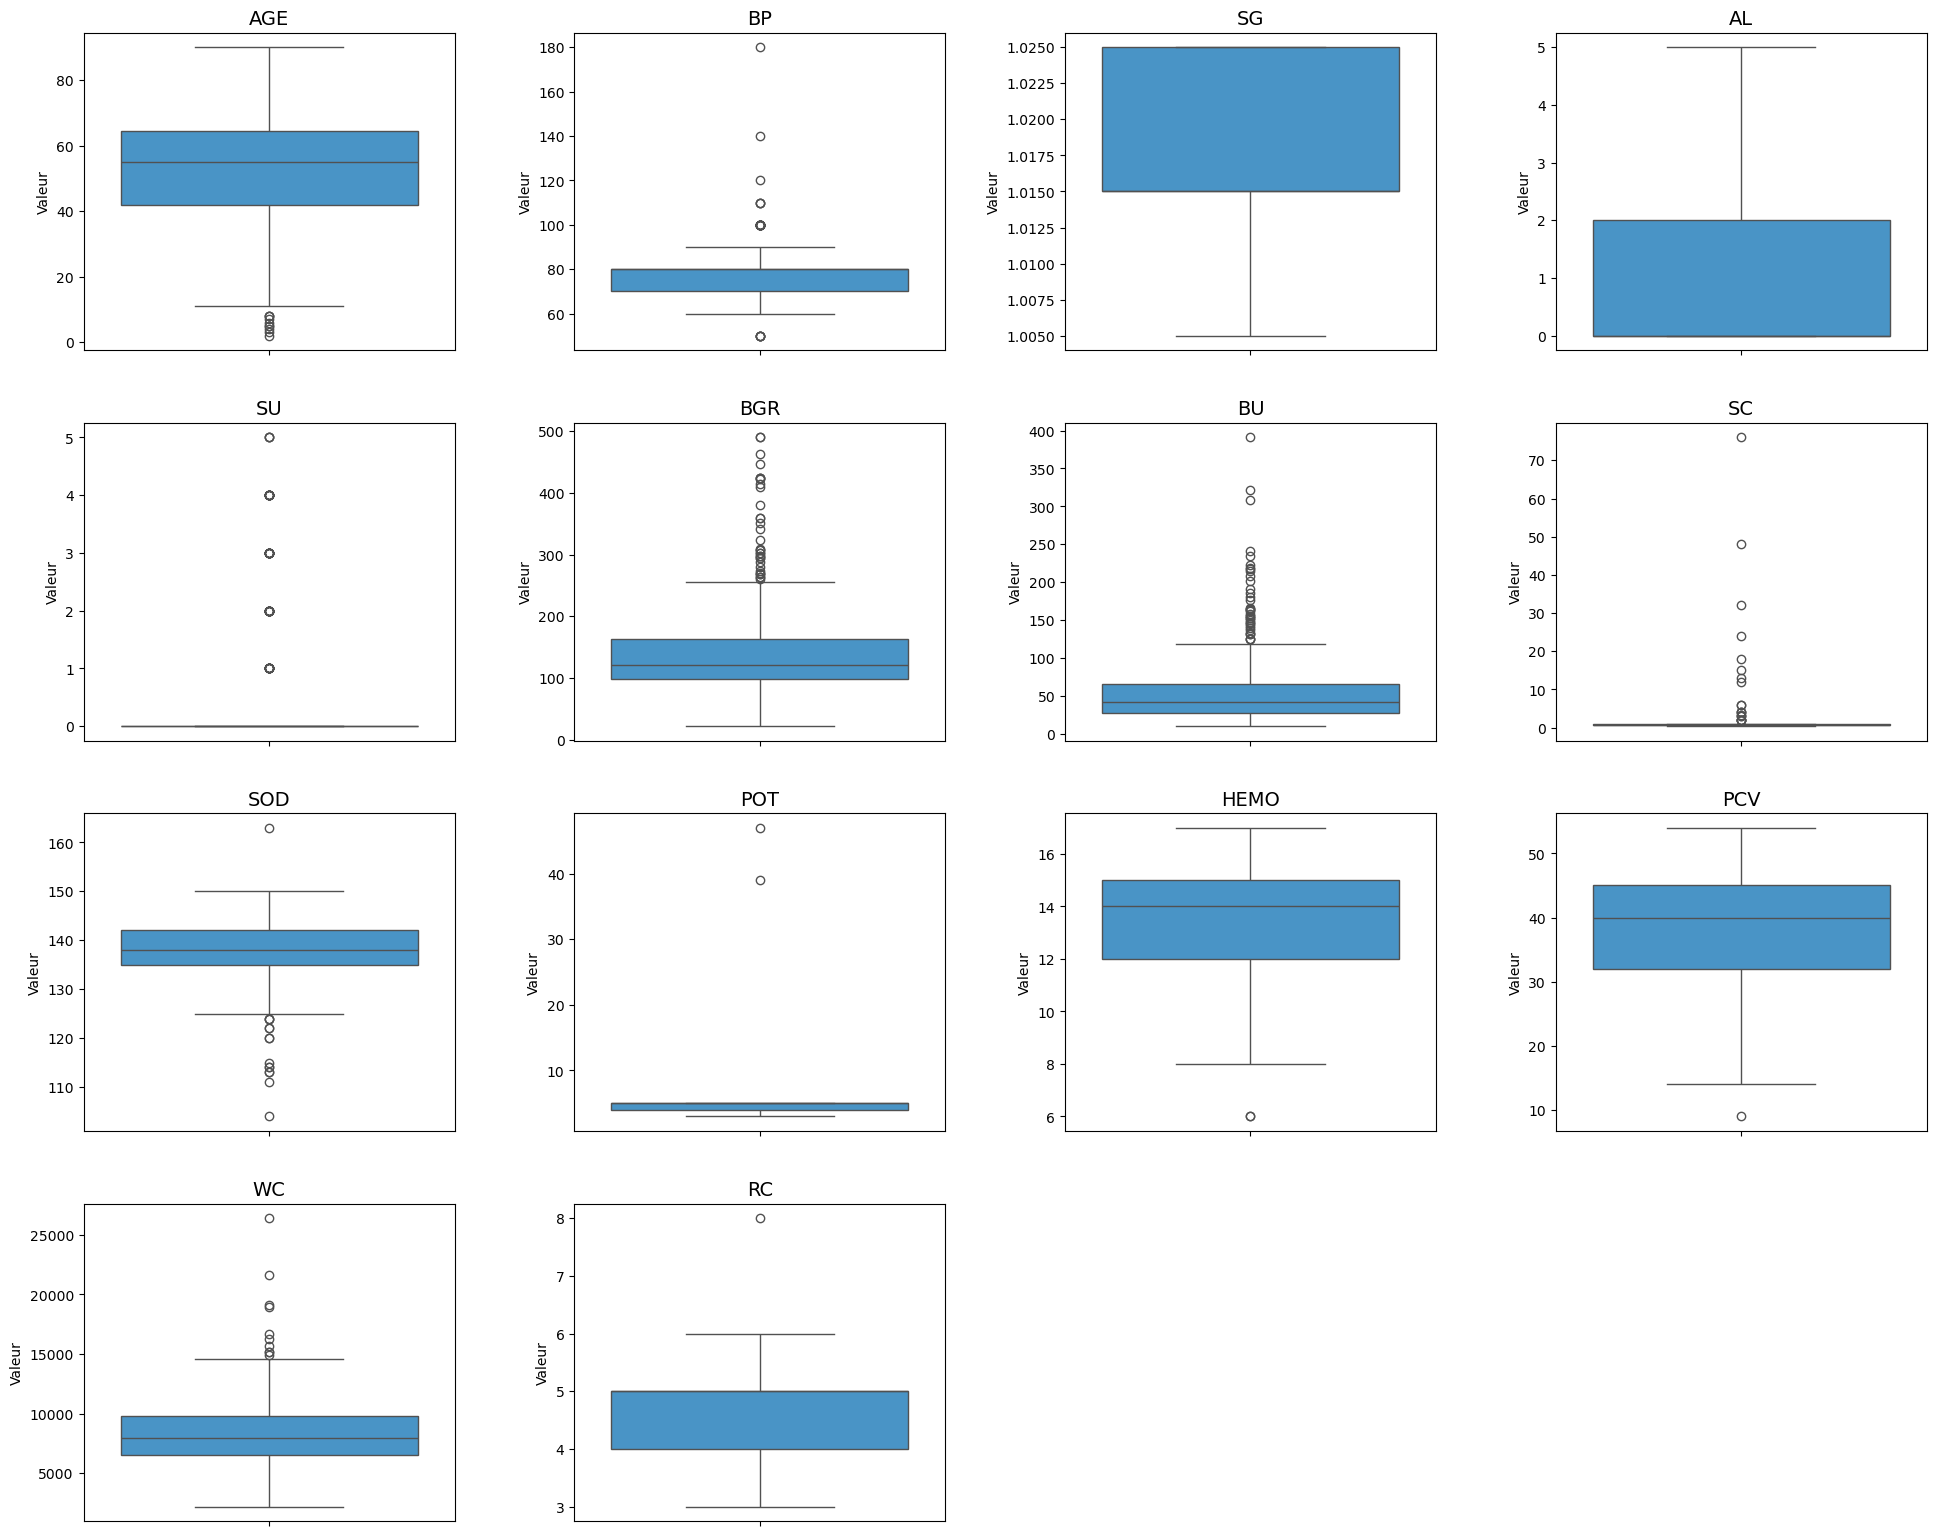

In [194]:
n_cols = 4
n_rows = len(numerical_cols)// n_cols + (len(numerical_cols) % n_cols > 0)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten() 

for i, col in enumerate(numerical_cols):
    if col in data.columns:
        sns.boxplot(y=data[col], ax=axes[i], color='#3498db')
        axes[i].set_title(f'{col.upper()}', fontsize=14)
        axes[i].set_ylabel(f"Valeur")
# Masquer les axes inutilisés
for j in range(len(numerical_cols_to_plot), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout(pad=3.0)
plt.show()

In [195]:
missing_counts = data.isnull().sum()
# Calculer le pourcentage de NaN par colonne
total_rows = len(data)
missing_percentage = (missing_counts / total_rows) * 100
print("missing percentage:",missing_percentage)
# Créer le DataFrame récapitulatif
missing_summary = pd.DataFrame({
    'Total NaN': missing_counts,
    'Pourcentage (%)': missing_percentage
})

missing percentage: age                2.25
bp                 3.00
sg                59.25
al                11.50
su                12.25
rbc               38.00
pc                16.25
pcc                1.00
ba                 1.00
bgr               11.00
bu                 5.00
sc                63.25
sod               22.00
pot               88.00
hemo              86.75
pcv               17.75
wc                26.50
rc                94.00
htn                0.50
dm                 0.50
cad                0.50
appet              0.25
pe                 0.25
ane                0.25
classification     0.00
dtype: float64


In [196]:
# Trier par pourcentage de valeurs manquantes (croissant)
missing_summary = missing_summary[missing_summary['Total NaN'] > 0].sort_values('Pourcentage (%)', ascending=True)

print("Résumé des valeurs manquantes (trié par pourcentage croissant) :", missing_summary)

Résumé des valeurs manquantes (trié par pourcentage croissant) :        Total NaN  Pourcentage (%)
ane            1             0.25
appet          1             0.25
pe             1             0.25
dm             2             0.50
cad            2             0.50
htn            2             0.50
pcc            4             1.00
ba             4             1.00
age            9             2.25
bp            12             3.00
bu            20             5.00
bgr           44            11.00
al            46            11.50
su            49            12.25
pc            65            16.25
pcv           71            17.75
sod           88            22.00
wc           106            26.50
rbc          152            38.00
sg           237            59.25
sc           253            63.25
hemo         347            86.75
pot          352            88.00
rc           376            94.00


### Le tableau des pourcentages manquants montre clairement que l'imputation est absolument nécessaire, surtout pour des variables clés comme rbc (38%), rc (32.5%), wc (26.25%), et les électrolytes sod (21.75%) et pot (22%).

In [197]:
n_dupl = data.duplicated().sum()
print(f"Nombre de lignes duplique:{n_dupl}")

if n_dupl > 0:
    data.drop_duplicated(inplace=True)
    print(f"Suppression de {n_dupl} doublons")    
else:
    print("Aucun doublon trouve!")

Nombre de lignes duplique:0
Aucun doublon trouve!


In [198]:
#traitement des outliers
for col in numerical_cols:
    if col in data.columns and data[col].dtype in [np.float64, np.int64]:
        # Plafonnement au 5e et 95e centiles
        lower_bound = data[col].quantile(0.05)
        upper_bound = data[col].quantile(0.95)
        
        data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
        data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])

In [199]:
# Mappage Binaire des étiquettes en 0 et 1
binary_mapping = {
    'yes': 1, 'no': 0, 'present': 1, 'notpresent': 0, 'abnormal': 1, 'normal': 0,
    'poor': 1, 'good': 0, 'ckd': 1, 'notckd': 0
}

for col in categorical_cols + [target_col]:
    if col in data.columns:
        # Nettoyage des chaînes de caractères
        data[col] = data[col].astype(str).str.lower().str.strip()
        # Application du mappage 0/1
        data[col].replace(binary_mapping, inplace=True)
        # (les erreurs non mappées deviennent NaN)
        data[col] = pd.to_numeric(data[col], errors='coerce') 
        #apres ceci les colonnes sont en NaN ou numerique

In [200]:
#IMPUTATION (Médiane ; Mode)
# Imputation par la MÉDIANE pour le numérique
for col in numerical_cols:
    if col in data.columns and data[col].isnull().any():
        col_median = data[col].median()
        data[col].fillna(col_median, inplace=True)


# Imputation par le MODE pour le catégoriel/binaire 
for col in categorical_cols:
    if col in data.columns and data[col].isnull().any():
        # Assurez-vous que l'encodage 0/1 est fait avant cette étape pour le Mode
        mode_val = data[col].mode()[0]
        data[col].fillna(mode_val, inplace=True)
        data[col] = data[col].astype(int)

## Mise a l'echelle des variables numerique

In [201]:
# STANDARDISATION 

print("Standardisation")
cols_to_scale = [col for col in numerical_cols if col in data.columns]

scaler = StandardScaler()
data[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])

print(data.head())

Standardisation
        age        bp        sg        al        su  rbc  pc  pcc  ba  \
0 -0.243795  0.321342 -0.503903  0.078568 -0.396853    0   0    0   0   
1 -2.101894 -1.403986 -0.503903  2.378115 -0.396853    0   0    0   0   
2  0.653218  0.321342 -0.503903  0.845083  3.029216    0   0    0   0   
3 -0.243795 -0.541322 -0.503903  2.378115 -0.396853    0   1    1   0   
4 -0.051578  0.321342 -0.503903  0.845083 -0.396853    0   0    0   0   

        bgr  ...       pcv        wc        rc  htn  dm  cad  appet  pe  ane  \
0 -0.331723  ...  0.623599 -0.191628  0.073175    1   1    0      0   0    0   
1 -0.331723  ... -0.164520 -1.096957  0.073175    0   0    0      0   0    0   
2  2.701708  ... -1.083992 -0.342516  0.073175    0   1    0      1   0    1   
3 -0.396870  ... -0.952639 -0.744885  0.073175    1   0    0      1   1    1   
4 -0.576026  ... -0.558579 -0.443108  0.073175    0   0    0      0   0    0   

   classification  
0               1  
1               1  
2   

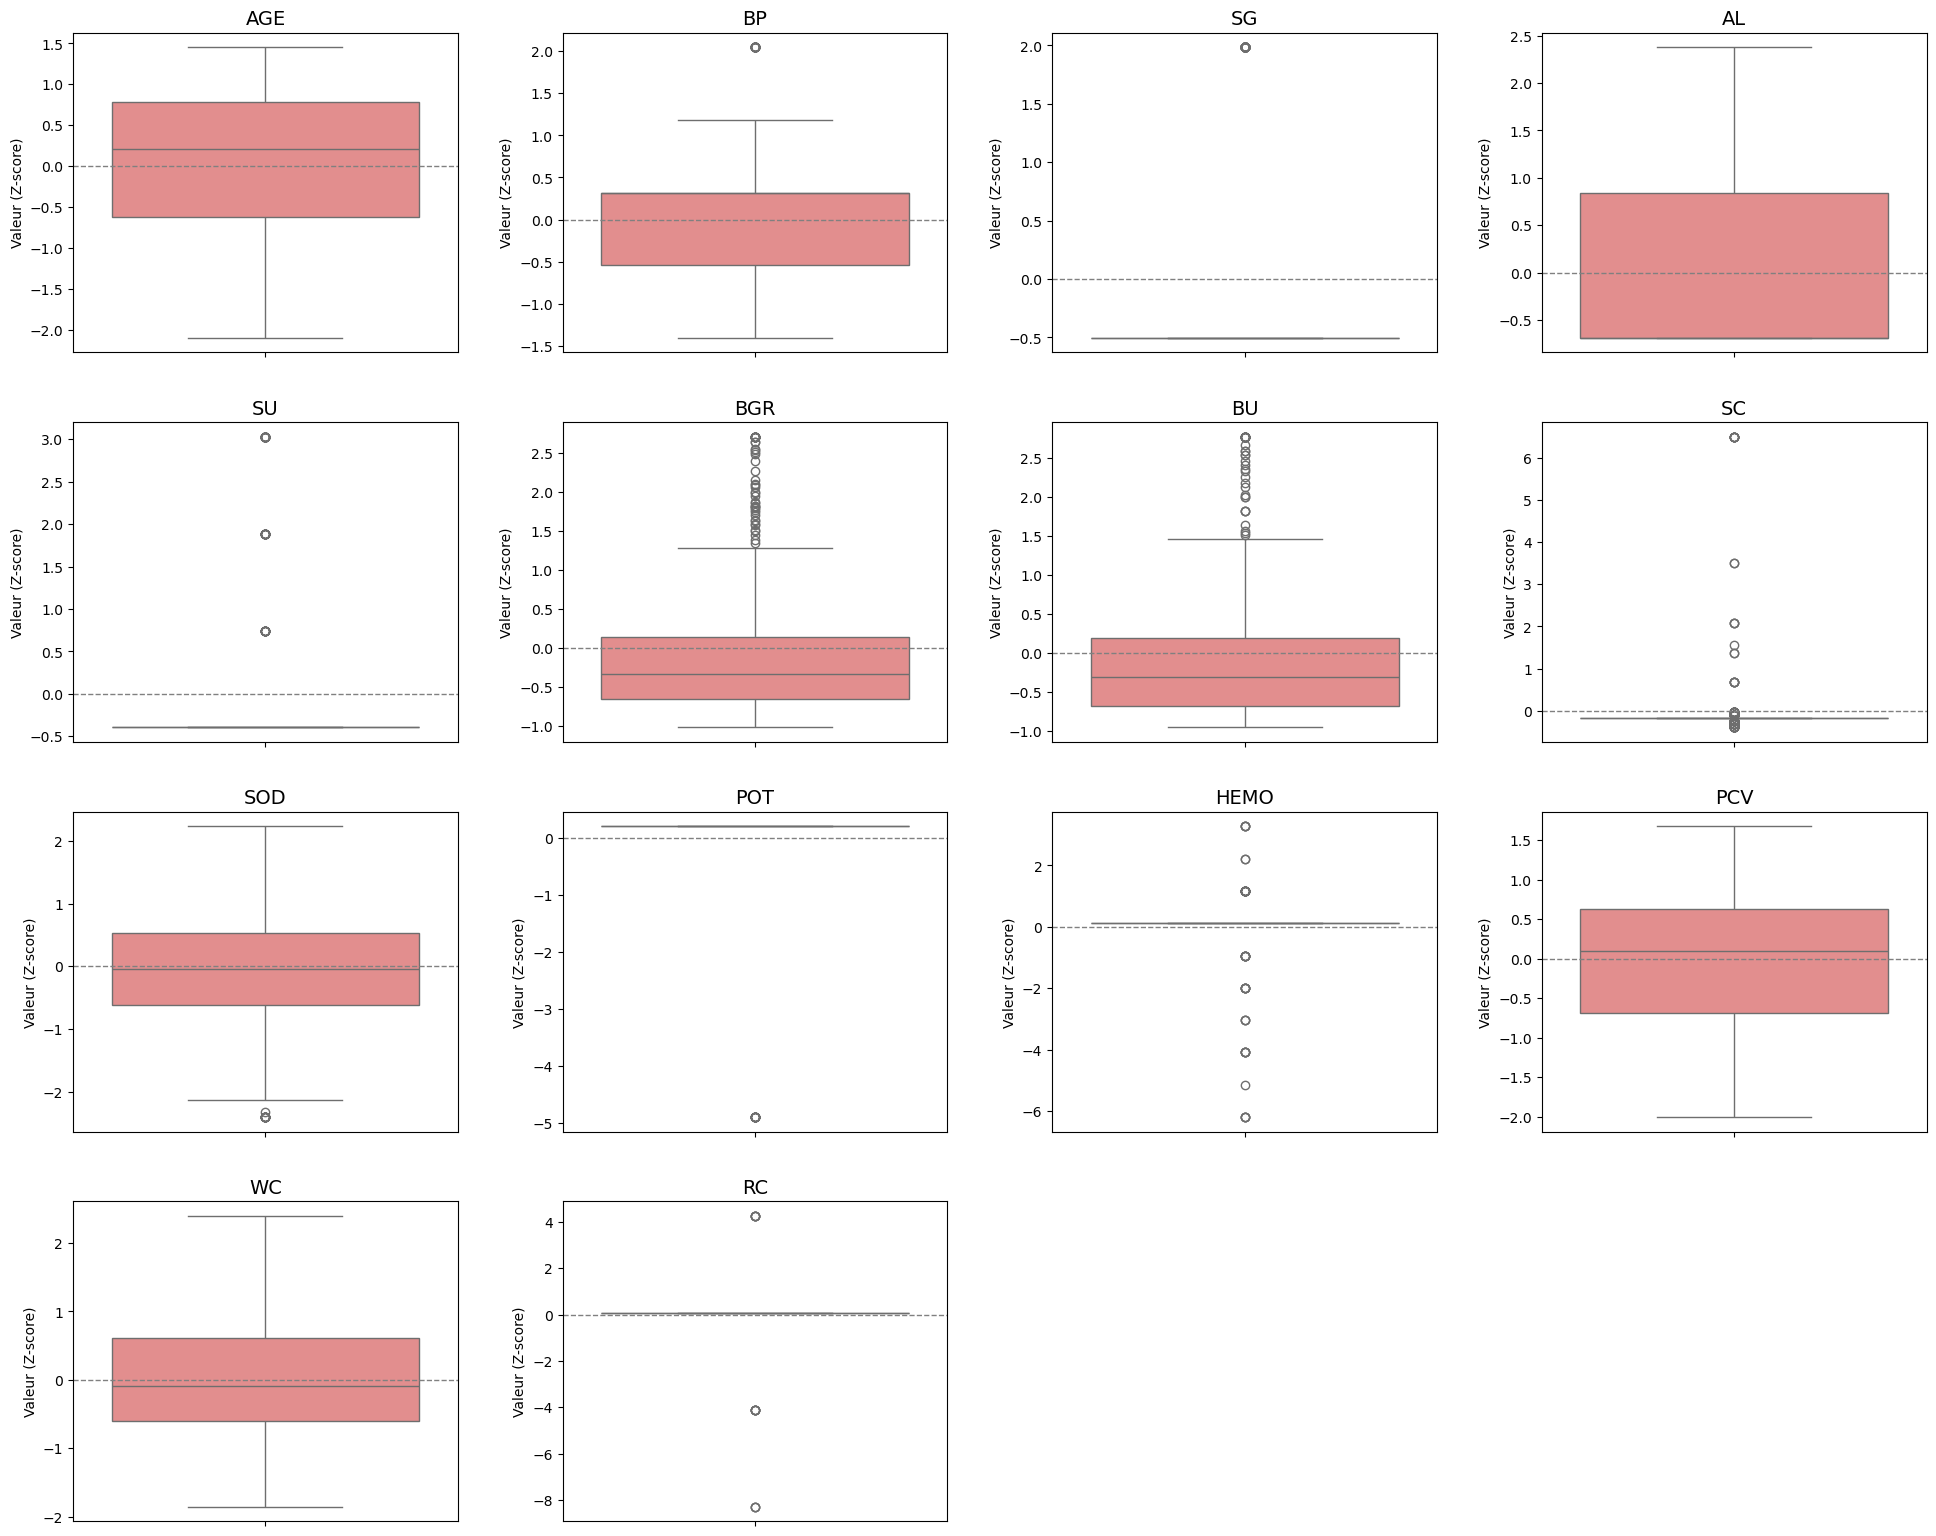

In [202]:
#Visualisation des outliers apres le traitement
n_cols = 4  # 4 graphiques par ligne
n_rows = len(numerical_cols_to_plot) // n_cols + (len(numerical_cols_to_plot) % n_cols > 0)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten() 

for i, col in enumerate(numerical_cols_to_plot):
    if col in data.columns:
     
        sns.boxplot(y=data[col], ax=axes[i], color='lightcoral')
        axes[i].set_title(f'{col.upper()}', fontsize=14)
        axes[i].set_ylabel(f"Valeur (Z-score)")
        
        axes[i].axhline(0, color='gray', linestyle='--', linewidth=1)

# Masquer les axes inutilisés
for j in range(len(numerical_cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=3.0)
plt.show()

In [203]:
profile_cols = [col for col in data.columns if col not in ['id', 'classification']]

# Calcul des profils moyens standardisés
# La moyenne des Z-scores est la signature du profil
df_radar = data.groupby('classification')[profile_cols].mean()

In [204]:
import pandas as pd
import numpy as np

# 1. PRÉPARATION DU TABLEAU D'ÉCARTS
# S'assurer que seules les colonnes numériques sont incluses
numeric_profile_cols = data.select_dtypes(include=np.number).columns.tolist()

# Exclure la variable cible
profile_cols_final = [col for col in numeric_profile_cols if col != 'classification']

# Calcul des profils moyens standardisés
# La moyenne représente l'ÉCART-TYPE par rapport à la moyenne générale (0)
df_profil = data.groupby('classification')[profile_cols_final].mean().T # .T pour transposer et avoir les variables en lignes

# Renommer les colonnes pour la lisibilite
df_profil.columns = ['Profil Sain (0)', 'Profil CKD (1)']

# Calculer l'ÉCART ABSOLU entre les deux groupes pour classer les différences
df_profil['Différence Absolue'] = np.abs(df_profil['Profil CKD (1)'] - df_profil['Profil Sain (0)'])

# Trier par la différence pour identifier les facteurs clés
df_profil_final = df_profil.sort_values(by='Différence Absolue', ascending=False)

print(df_profil_final)

......TABLEAU D'ANALYSE DES ÉCARTS STANDARDISÉS (CONSIGNE 1) .....
       Profil Sain (0)  Profil CKD (1)  Différence Absolue
pcv           0.897689       -0.538614            1.436303
al           -0.687948        0.412769            1.100716
sg            0.657355       -0.394413            1.051768
sod           0.640344       -0.384207            1.024551
bu           -0.535026        0.321016            0.856042
bgr          -0.534766        0.320860            0.855626
bp           -0.414798        0.248879            0.663676
su           -0.396853        0.238112            0.634965
htn           0.000000        0.588000            0.588000
dm            0.000000        0.548000            0.548000
age          -0.336700        0.202020            0.538720
hemo          0.293479       -0.176087            0.469566
wc           -0.229518        0.137711            0.367228
sc           -0.215422        0.129253            0.344675
appet         0.000000        0.328000          

#### A. Signature du Profil CKD (Malade) ####

#### Ce profil se caractérise par des scores standardisés positifs sur les facteurs de risque et des scores négatifs sur les facteurs de protection :

#### Détérioration Rénale (Filtres défaillants) : Taux très élevés (positifs) d'Albumine (al=+0.41) et d'Urée Sanguine (bu=+0.32). ####
#### Déficits d'Anémie : Taux très faibles (négatifs) de Volume Cellulaire (pcv=−0.54), d'Hémoglobine (hemo=−0.18) et de Globules Rouges (rc=−0.09). ####

#### Comorbidités : Forte présence (htn=+0.59 et dm=+0.55) d'Hypertension et de Diabète. ####

#### B. Signature du Profil Sain (Non-CKD) ####

#### Ce profil se caractérise par des scores standardisés positifs sur les facteurs de protection et des scores négatifs sur les facteurs de risque : ####

  ####  Bonne Santé Rénale : Taux élevés (positifs) de Volume Cellulaire (pcv=+0.90) et de Sodium (sod=+0.64). ####

#### Faibles Risques : Taux très faibles (négatifs) d'Albumine (al=−0.69), de Glucose (bgr=−0.53) et d'Urée (bu=−0.54). ####

In [205]:
from scipy import stats
# Séparer les données en deux groupes
ckd_group = data[data['classification'] == 1]
non_ckd_group = data[data['classification'] == 0]

# Variables à tester 
variables_a_tester = ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad','appet', 'pe', 'ane']


for col in variables_a_tester:
    # Effectuer le test t d'échantillons indépendants
    # Nous utilisons equal_var=False (test de Welch) car les variances peuvent être inégales
    t_stat, p_value = stats.ttest_ind(
        ckd_group[col],
        non_ckd_group[col],
        equal_var=False,
        nan_policy='omit' 
    )
    
    # Interprétation (si p < 0.05, la différence est réelle)
    significatif = "Oui" if p_value < 0.05 else "Non"
    
    print(f"\nVariable : {col.upper()}")
    print(f"  Statistique t : {t_stat:.3f}")
    print(f"  Valeur p : {p_value:.5f}")
    print(f"  Différence Statistique : {significatif} (seuil p < 0.05)")


Variable : AGE
  Statistique t : 5.375
  Valeur p : 0.00000
  Différence Statistique : Oui (seuil p < 0.05)

Variable : BP
  Statistique t : 7.382
  Valeur p : 0.00000
  Différence Statistique : Oui (seuil p < 0.05)

Variable : SG
  Statistique t : -9.855
  Valeur p : 0.00000
  Différence Statistique : Oui (seuil p < 0.05)

Variable : AL
  Statistique t : 16.227
  Valeur p : 0.00000
  Différence Statistique : Oui (seuil p < 0.05)

Variable : SU
  Statistique t : 8.324
  Valeur p : 0.00000
  Différence Statistique : Oui (seuil p < 0.05)

Variable : RBC
  Statistique t : 7.593
  Valeur p : 0.00000
  Différence Statistique : Oui (seuil p < 0.05)

Variable : PC
  Statistique t : 10.429
  Valeur p : 0.00000
  Différence Statistique : Oui (seuil p < 0.05)

Variable : PCC
  Statistique t : 7.091
  Valeur p : 0.00000
  Différence Statistique : Oui (seuil p < 0.05)

Variable : BA
  Statistique t : 4.902
  Valeur p : 0.00000
  Différence Statistique : Oui (seuil p < 0.05)

Variable : BGR
  Stat

In [206]:
# La variable cible pour les STADES est la Créatinine Sérique (sc)
Y_stades = data['sc']
X_stades = data.select_dtypes(include=np.number).drop(columns=['sc'], errors='ignore')

# la variable cible 'classification' est exclue des features
if 'classification' in X_stades.columns:
    X_stades = X_stades.drop(columns=['classification'])

# 2. SÉPARATION DES DONNÉES 
X_train, X_test, Y_train, Y_test = train_test_split(
    X_stades, Y_stades, test_size=0.2, random_state=42
)

# 3. ENTRAÎNEMENT DU MODÈLE
linear_model = LinearRegression()
linear_model.fit(X_train, Y_train)

# 4. ÉVALUATION (R-squared, mesure de la qualité de l'ajustement)
r2_score = linear_model.score(X_test, Y_test)
print(f"Qualité de l'ajustement (R-squared) du Modèle Linéaire : {r2_score:.4f}")

# 5. EXTRACTION ET INTERPRÉTATION DES COEFFICIENTS
coefficients = linear_model.coef_
features = X_stades.columns

# Création du DataFrame des résultats
stade_df = pd.DataFrame({
    'Variable': features,
    'Coefficient': coefficients
})

# Trier par l'impact absolu
stade_df['Impact Absolu'] = np.abs(coefficients)
stade_df = stade_df.sort_values(by='Impact Absolu', ascending=False).reset_index(drop=True)
print(stade_df.head(10))

Qualité de l'ajustement (R-squared) du Modèle Linéaire : -0.0724
  Variable  Coefficient  Impact Absolu
0       bu     0.409871       0.409871
1      htn    -0.349957       0.349957
2      pcc    -0.321197       0.321197
3       pc     0.298945       0.298945
4      ane    -0.287766       0.287766
5       dm     0.133991       0.133991
6    appet    -0.113239       0.113239
7     hemo    -0.090723       0.090723
8      cad     0.082965       0.082965
9      rbc    -0.078553       0.078553


In [212]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# 1. Préparation (réutilisation de X et Y standardisés)
X = data.select_dtypes(include=np.number).drop(columns=['classification'], errors='ignore')
Y = data['classification']

# 2. Séparation des données (si ce n'est pas déjà fait)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# 3. Entraînement du modèle
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, Y_train)

# 4. Évaluation
score = rf_model.score(X_test, Y_test)
print(f"Précision du Modèle (Random Forest) : {score:.4f}")

# 5. Extraction de l'Importance des Variables
feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("\nIMPORTANCE DES VARIABLES (Random Forest)\n")
print(feature_importance.head(10))

Précision du Modèle (Random Forest) : 0.9750

IMPORTANCE DES VARIABLES (Random Forest)

  Variable  Importance
0      pcv    0.291212
1       al    0.111412
2      htn    0.094709
3       dm    0.081998
4       bu    0.064930
5      sod    0.064062
6       sg    0.054394
7      bgr    0.053215
8       bp    0.028601
9      age    0.024629


###### BU (Urée Sanguine),+0.409,Augmentation,Le facteur le plus puissant associé à l'aggravation. Une augmentation d'Urée correspond directement à une augmentation de sc (mauvaise filtration).
###### PC (Cellules Péliques),+0.298,Augmentation,Marqueur de dommage rénal. Son augmentation aggrave le stade.
###### DM (Diabète),+0.134,Augmentation,"Le Diabète pousse la Créatinine vers le haut, contribuant à l'avancement de la maladie."

###### Indicateurs de Gravité pour la diminution

###### Ces variables sont des signes de la maladie avancée et diminuent lorsque la Créatinine (sc) est élevée :

###### HTN (−0.349) : L'impact négatif est difficile à interpréter seul dans ce modèle, mais il suggère une relation complexe.

###### PCC (−0.321) et ANE (−0.287) : Ces marqueurs (cellules anormales, anémie) sont les conséquences d'un stade avancé.

###### Le R2 négatif (-0.0724) de la Régression Linéaire confirme que bien que les coefficients soient utiles pour interpréter l'influence, ce modèle ne serait pas fiable pour prédire la valeur exacte de la Créatinine. Le modèle Random Forest est de loin plus fiable pour la classification.